This report is a preliminary investigation of feature selection on safety data.
Feature selection is an important process that selects features which contribute most to machine learning models.
A correlation-based filter type method of feature selection is applied in this report to find out the relevance of features from a safety dataset.
The report shows that the feature selection method can efficiently improve a machine learning model' performance by providing relevant features.

The report represents the programming process of the feature selection method and its result.
Python is selected as the programming language and Jupyter Notebook is the programming environment to generate this report conveniently.
Thus, each programming cell will follows its computing result as well as explainations if needed.
The dataset comes from Appendix B of the project research report, data mining for workplace health and safety in New Zealand.


# data cleaning

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
data = pd.read_csv('impact.csv')
print("columns:\n", data.columns.values , "\n")
print("data overview: \n", data.head())
X = data.drop('TRIFR',1)   #Feature Matrix
y = data['TRIFR']          #Target Variable

columns:
 ['Rolling12DelayedActionCnt' 'DelayedPerEmp' 'AvgDelayedDays'
 'MinDelayedDays' 'MaxDelayedDays' 'AvgReqDays' 'MinReqDays' 'MaxReqDays'
 'AvgActualDays' 'MinActualDays' 'MaxActualDays' 'NM_MonthlyCount'
 'NM_Rolling12NMCount' 'TrainingCount5Years' 'AuditCount5Years' 'TRIFR'] 

data overview: 
    Rolling12DelayedActionCnt  DelayedPerEmp  AvgDelayedDays  MinDelayedDays  \
0                        132           0.61              65               1   
1                         92           0.42              78               1   
2                         90           0.41              81               1   
3                         89           0.41              82               1   
4                        132           0.61              65               1   

   MaxDelayedDays  AvgReqDays  MinReqDays  MaxReqDays  AvgActualDays  \
0             699         146        -699         619            212   
1             528          78        -528         577            156   
2   

# show Pearson / Kendall / Spearman correlation among all features

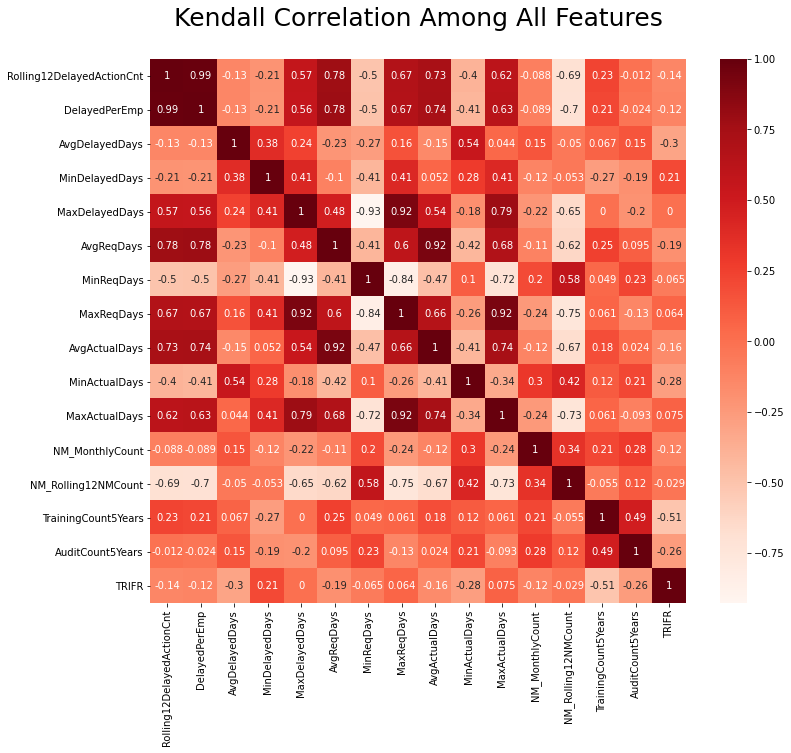

In [4]:
# HY Using Kendall Correlation
plt.figure(figsize=(12,10))
plt.title('Kendall Correlation Among All Features', fontsize=25, y= 1.05)
cor = data.corr(method = 'kendall')
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

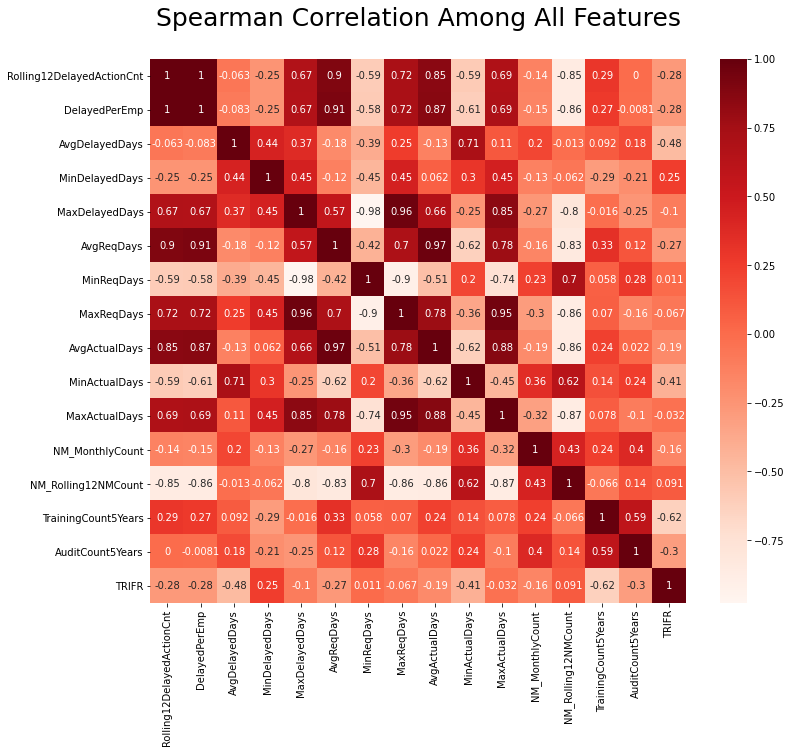

In [5]:
# HY Using Spearman Correlation
plt.figure(figsize=(12,10))
plt.title('Spearman Correlation Among All Features', fontsize=25, y= 1.05)
cor = data.corr(method = 'spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

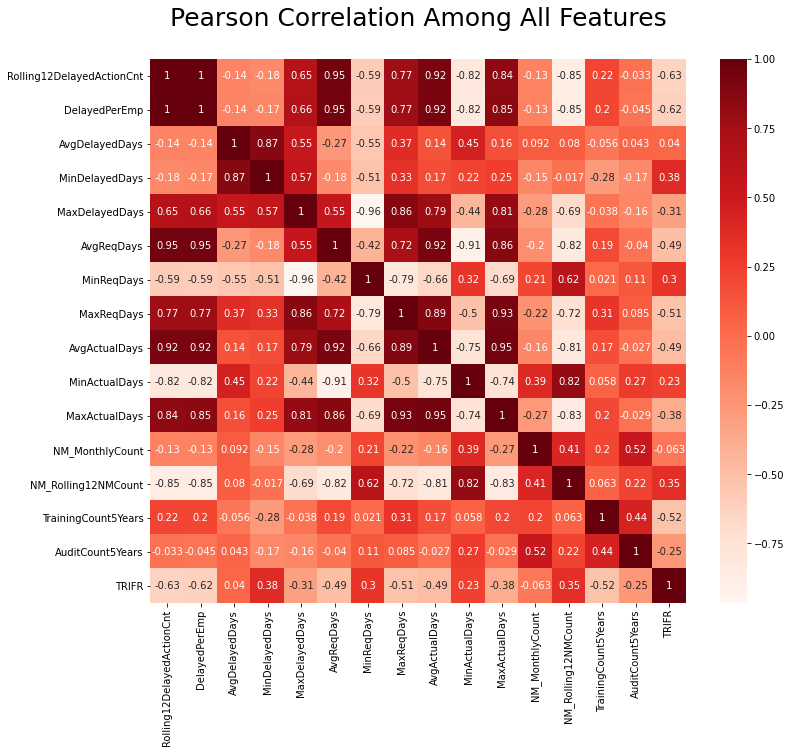

In [6]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
plt.title('Pearson Correlation Among All Features', fontsize=25, y= 1.05)
cor = data.corr(method = 'pearson')  # HY Added explict Method parameter - empty value defaults to Pearson
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

# selecting relevant features

In [7]:
#Correlation with output variable
cor_target = abs(cor['TRIFR'])
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0.5]
relevant_features

Rolling12DelayedActionCnt    0.633931
DelayedPerEmp                0.616705
MaxReqDays                   0.514971
TrainingCount5Years          0.519079
TRIFR                        1.000000
Name: TRIFR, dtype: float64

In [8]:
relevant_features = relevant_features.drop(index=['TRIFR'])
print("relevent features:",relevant_features.index.values)
relevant_features

relevent features: ['Rolling12DelayedActionCnt' 'DelayedPerEmp' 'MaxReqDays'
 'TrainingCount5Years']


Rolling12DelayedActionCnt    0.633931
DelayedPerEmp                0.616705
MaxReqDays                   0.514971
TrainingCount5Years          0.519079
Name: TRIFR, dtype: float64

# check the correlation within these relevant features

The features of Rolling12DelayedActionCnt, DelayedPerEmp, MaxReqDays and
TrainingCount5Years are highly correlated with the targeted variable TRIFR.
Then, check if these variables are correlated with each other in the next step.

In [9]:
print(data[relevant_features.index.values].corr())

                           Rolling12DelayedActionCnt  DelayedPerEmp  \
Rolling12DelayedActionCnt                   1.000000       0.999556   
DelayedPerEmp                               0.999556       1.000000   
MaxReqDays                                  0.774892       0.772765   
TrainingCount5Years                         0.217411       0.203230   

                           MaxReqDays  TrainingCount5Years  
Rolling12DelayedActionCnt    0.774892             0.217411  
DelayedPerEmp                0.772765             0.203230  
MaxReqDays                   1.000000             0.306577  
TrainingCount5Years          0.306577             1.000000  


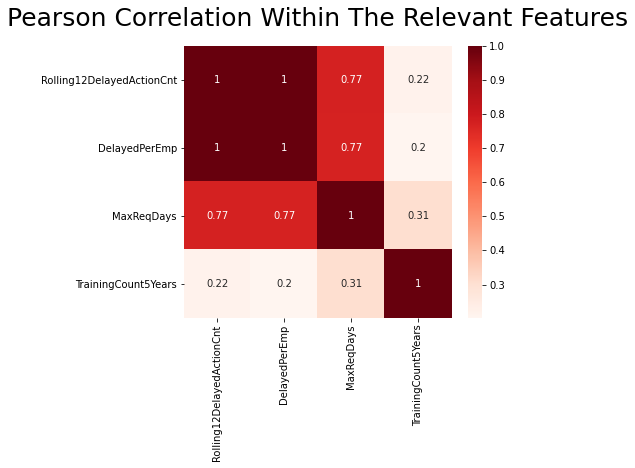

In [10]:
plt.figure(figsize=(6,5))
plt.title('Pearson Correlation Within The Relevant Features', fontsize=25, y=1.05)
cor = data[relevant_features.index.values].corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

These variables are highly correlated with each other: Rolling12DelayedActionCnt and DelayedPerEmp (0.999556), Rolling12DelayedActionCnt and MaxReqDays (0.774892).
Thus, drop these two variables (e.g. DelayedPerEmp and MaxReqDays) and left two variables of Rolling12DelayedActionCnt and TrainingCount5Years as the final features given by Pearson correlation. 

# apply to a linear regression model

## define a machine learning model for evaluation

In [11]:
def run_LinearRegression(X_train, X_test, y_train, y_test):
    # fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    # evaluate the model
    yhat = model.predict(X_test)
    # evaluate predictions
    mae = mean_absolute_error(y_test, yhat)
    print('MAE: %.3f' % mae)
    return mae

## the model's performance without feature selection

In [12]:
X_train, X_test, y_train, y_test =  \
train_test_split(X,y, test_size = 0.2, random_state = 0)

In [23]:
%time
mae = run_LinearRegression(X_train, X_test, y_train, y_test)

Wall time: 0 ns
MAE: 41.098


## the model's performance with feature selection

In [24]:
X_train_f, X_test_f, y_train_f, y_test_f =  \
train_test_split(X[['Rolling12DelayedActionCnt', 'TrainingCount5Years']],y, \
                 test_size = 0.2, random_state = 0)

In [25]:
%time
mae_f = run_LinearRegression(X_train_f, X_test_f, y_train_f, y_test_f)

Wall time: 0 ns
MAE: 1.594


In [26]:
print("The feature selction approach reduces ",round((mae- mae_f)/mae*100, 1), \
      "% of the mean_absolute_error of the model.")

The feature selction approach reduces  96.1 % of the mean_absolute_error of the model.


In [15]:
import math 
3*0.3636*math.sqrt(12*11)/math.sqrt(4*12+2*5)

1.6455765810614622